In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin1')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
df.shape

(9994, 21)

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [11]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month

df['YearMonth'] = df['Order Date'].dt.to_period('M')

In [12]:
df[['Order Date','Year','Month','YearMonth']].head()

,Order Date,Year,Month,YearMonth
0,2016-11-08,2016,11,2016-11
1,2016-11-08,2016,11,2016-11
2,2016-06-12,2016,6,2016-06
3,2015-10-11,2015,10,2015-10
4,2015-10-11,2015,10,2015-10


In [13]:
total_revenue = df['Sales'].sum()

total_profit = df['Profit'].sum()

profit_margin = (total_profit / total_revenue) * 100

print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin %:", round(profit_margin, 2))

Total Revenue: 2297200.86
Total Profit: 286397.02
Profit Margin %: 12.47


In [14]:
total_orders = df['Order ID'].nunique()

aov = total_revenue / total_orders

print("Total Orders:", total_orders)
print("Average Order Value:", round(aov, 2))

Total Orders: 5009
Average Order Value: 458.61


In [15]:
revenue_by_region = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

revenue_by_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [17]:
profit_by_region = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

profit_by_region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [18]:
profit_margin_region = (
    (df.groupby('Region')['Profit'].sum() /
     df.groupby('Region')['Sales'].sum()) * 100
).sort_values(ascending=False)

profit_margin_region.round(2)

Region
West       14.94
East       13.48
South      11.93
Central     7.92
dtype: float64

In [19]:
category_analysis = df.groupby('Category').agg({
    'Sales':'sum',
    'Profit':'sum'
}).round(2)

category_analysis

,Sales,Profit
Category,,
Furniture,741999.80,18451.27
Office Supplies,719047.03,122490.80
Technology,836154.03,145454.95


In [20]:
category_analysis['Profit Margin %'] = (
    category_analysis['Profit']
    / category_analysis['Sales']
) * 100

category_analysis.round(2)

,Sales,Profit,Profit Margin %
Category,,,
Furniture,741999.80,18451.27,2.49
Office Supplies,719047.03,122490.80,17.04
Technology,836154.03,145454.95,17.40


In [21]:
top_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [23]:
bottom_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

bottom_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [24]:
segment_analysis = df.groupby('Segment').agg({
    'Sales':'sum',
    'Profit':'sum'
}).round(2)

segment_analysis

,Sales,Profit
Segment,,
Consumer,1161401.34,134119.21
Corporate,706146.37,91979.13
Home Office,429653.15,60298.68


In [25]:
monthly_revenue = (
    df.groupby('YearMonth')['Sales']
      .sum()
      .reset_index()
)

monthly_revenue.head()

,YearMonth,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


In [26]:
monthly_revenue.tail()

,YearMonth,Sales
43,2017-08,63120.8880
44,2017-09,87866.6520
45,2017-10,77776.9232
46,2017-11,118447.8250
47,2017-12,83829.3188


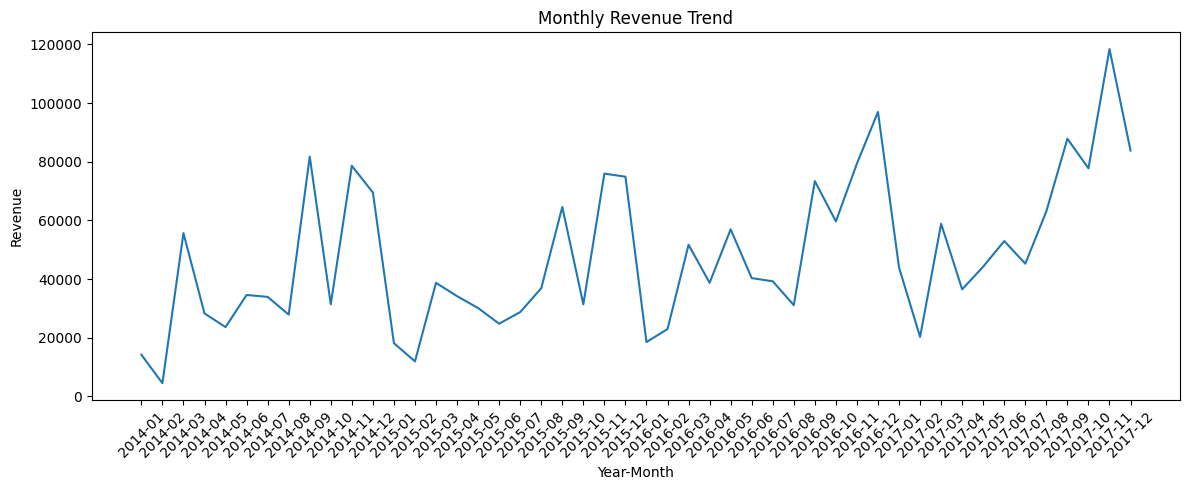

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue['YearMonth'].astype(str),
    monthly_revenue['Sales']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [28]:
monthly_profit = (
    df.groupby('YearMonth')['Profit']
      .sum()
      .reset_index()
)

monthly_profit.head()

,YearMonth,Profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299
3,2014-04,3488.8352
4,2014-05,2738.7096


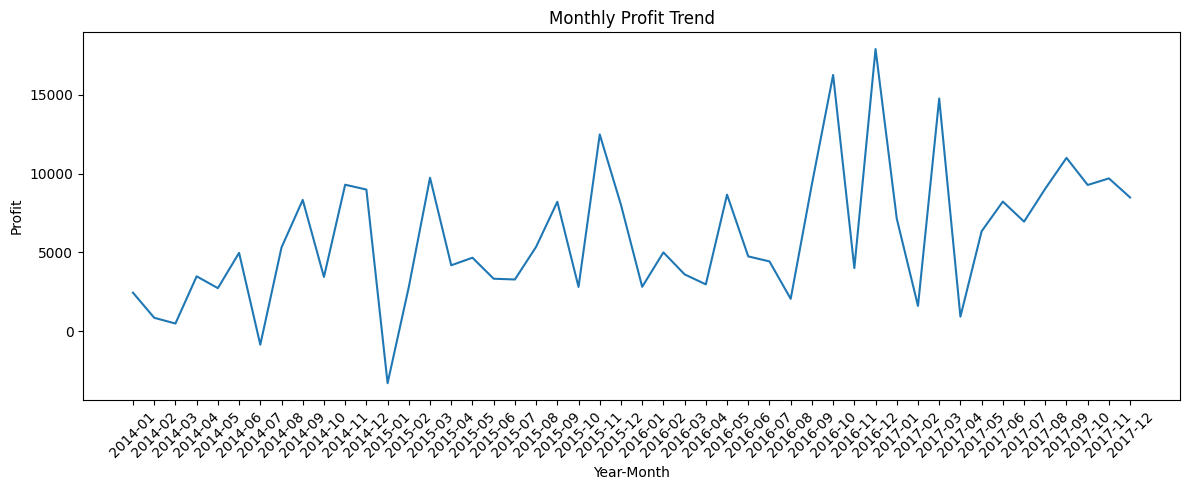

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_profit['YearMonth'].astype(str),
    monthly_profit['Profit']
)

plt.title('Monthly Profit Trend')
plt.xlabel('Year-Month')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [30]:
yearly_performance = df.groupby('Year').agg({
    'Sales':'sum',
    'Profit':'sum'
}).round(2)

yearly_performance

,Sales,Profit
Year,,
2014,484247.50,49543.97
2015,470532.51,61618.60
2016,609205.60,81795.17
2017,733215.26,93439.27


In [31]:
yearly_performance['Revenue Growth %'] = (
    yearly_performance['Sales']
    .pct_change() * 100
)

yearly_performance.round(2)

,Sales,Profit,Revenue Growth %
Year,,,
2014,484247.50,49543.97,NaN
2015,470532.51,61618.60,-2.83
2016,609205.60,81795.17,29.47
2017,733215.26,93439.27,20.36


In [32]:
df[['Sales','Profit','Discount']].describe()

,Sales,Profit,Discount
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203
std,623.245101,234.260108,0.206452
min,0.444000,-6599.978000,0.000000
25%,17.280000,1.728750,0.000000
50%,54.490000,8.666500,0.200000
75%,209.940000,29.364000,0.200000
max,22638.480000,8399.976000,0.800000


In [33]:
df.groupby('Discount')['Profit'].mean().round(2)

Discount
0.00     66.90
0.10     96.06
0.15     27.29
0.20     24.70
0.30    -45.68
0.32    -88.56
0.40   -111.93
0.45   -226.65
0.50   -310.70
0.60    -43.08
0.70    -95.87
0.80   -101.80
Name: Profit, dtype: float64

In [34]:
df.groupby('State')['Sales']\
  .sum()\
  .sort_values(ascending=False)\
  .head(10)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

In [35]:
df.groupby('State')['Profit']\
  .sum()\
  .sort_values(ascending=False)\
  .head(10)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

In [36]:
pd.pivot_table(
    df,
    values='Profit',
    index='Category',
    columns='Segment',
    aggfunc='sum'
).round(2)

Segment,Consumer,Corporate,Home Office
Category,,,
Furniture,6991.08,7584.82,3875.38
Office Supplies,56330.32,40227.32,25933.16
Technology,70797.81,44167.00,30490.14


In [37]:
df.to_csv('../exports/finance_analytics_final.csv', index=False)

print("Dataset exported successfully!")

Dataset exported successfully!
